In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ep_processing import *
from utils.visualization import * 

In [2]:
my_experiment_name = "amip"
my_runid = "agm-diagn-cc-amip"  # change this to "agm-amip-test",  "agm-diagn-cc-amip" or whatever experiment you want to look at!
base_outfile_str = "amip_diagn_experiment2" #"amip_baseline_experiment1" # "amip_diagn_experiment2"

# Some example paths if you're running of Trillium instead...
# my_base_path = "/scratch/agmorgan/canesm_runs/{runid}/data/nc_output/CMIP6/CMIP/CP4C/CanESM5-1/{experiment_name}/r1i1p1f1/"
# my_daily_path = "day/{var_name}/gn/v20190429/{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_file_path = "{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

In [3]:
# Need some info on grid areacells as well for benchmarking.

# my_ areacell_path = "fx/areacella/gn/v20190429/areacella_fx_CanESM5-1_{experiment_name}_r1i1p1f1_gn.nc"
my_areacell_path = "areacella_fx_CanESM5-1_amip_r1i1p1f1_gn.nc"

ds_areacella = get_ds_areacell(
                    my_runid, 
                    my_experiment_name,
                    base_path = my_base_path,
                    areacell_path = my_areacell_path,
)
global_area = ds_areacella.areacella.sum(dim=['lon', 'lat'])         

In [4]:
da_epr, da_eprc, da_eprr = get_ep_info(
    my_runid,
    my_experiment_name,
    year_range,
    base_path = my_base_path,
    file_path = my_file_path,
)

da_epr_mean = da_epr.mean(dim = "time")
da_eprc_mean = da_eprc.mean(dim = "time")
da_eprr_mean = da_eprr.mean(dim = "time")

da_epr_max = da_epr_mean.max().values

Let's make some maps to determine whether precipitaton partitioning occurs. 

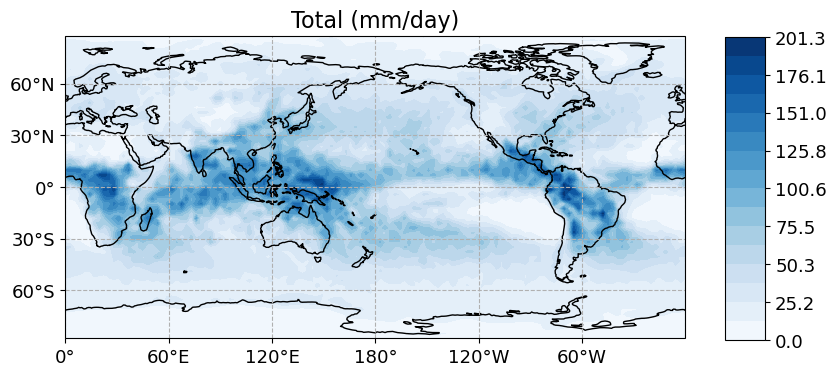

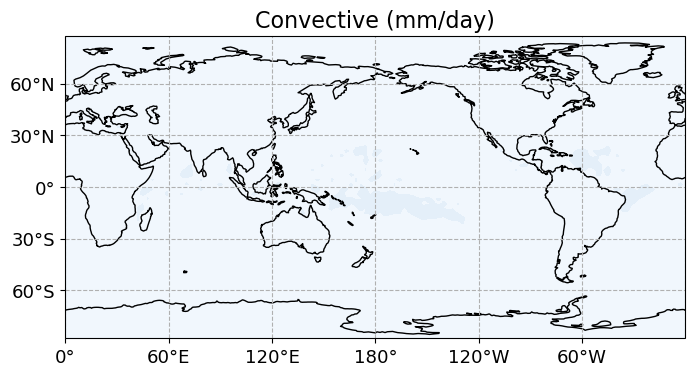

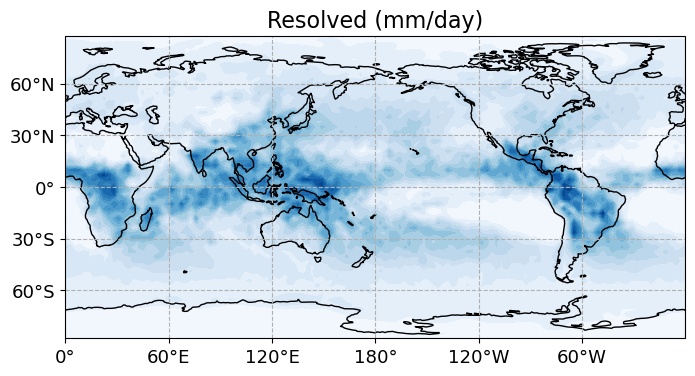

In [5]:
da_list = [da_epr_mean, da_eprc_mean, da_eprr_mean]
label_list = ["Total", "Convective", "Resolved"]

for da, label in zip(da_list, label_list):

    field_vals, lon_plt, lat_plt = process_for_map(da)
    draw_global_map(
        lon_plt,
        lat_plt,
        field_vals,
        title = label + " (mm/day)",
        filled = True,
        show_fig = True,
        save_fig = True,
        levels = 16,
        cmap = "Blues",
        cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
        vmin = 0,
        vmax = da_epr_max,
        draw_labels = False,
        label_contours = False,
        remove_cbar = True if label != "Total" else False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        outfilename = base_outfile_str + label + ".png",
    )

We now plot convective precip. on a different scale to get a better feel for the difference between total precip. and resolved precip. 

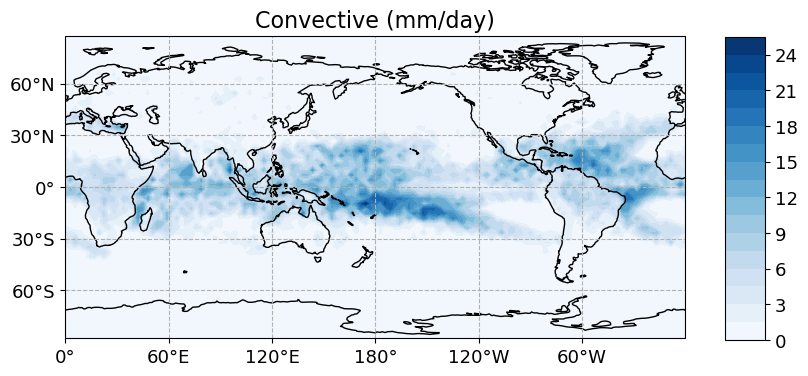

In [6]:
field_vals, lon_plt, lat_plt = process_for_map(da_eprc_mean)
draw_global_map(
        lon_plt,
        lat_plt,
        field_vals,
        title = "Convective (mm/day)",
        filled = True,
        show_fig = True,
        save_fig = True,
        levels = 16,
        cmap = "Blues",
        cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
        #vmin = 0,
        #vmax = da_epr_max,
        draw_labels = False,
        label_contours = False,
        remove_cbar = False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        outfilename = base_outfile_str + "_convection_rescaled" + ".png",
)

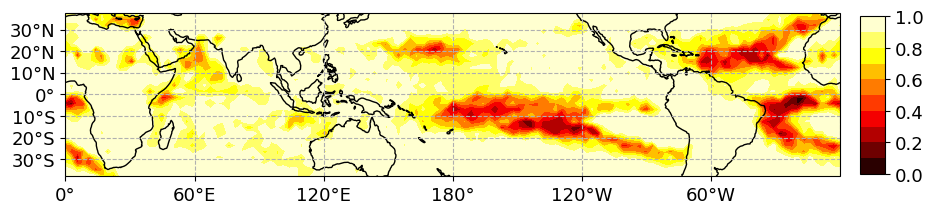

Area-weighted spatial mean of resolved fraction = 0.8575517535209656


In [8]:
tropical_halfwidth = 40. 
    
def get_resolved_ep_fraction_in_tropics(
        # da_pr,
        # da_prr,
        da_epr,
        da_eprr,
        ds_areacell,
        tropical_halfwidth = 23.4,
):
    """
    Get the fraction of convective precipitation in the tropics
    """
    conv = MM_PER_H_TO_MM_PER_D_CONVERSION_FACTOR

    # climatology_das = [
    #     da.mean(dim = "time") for da in [da_pr, da_prr]
    # ]

    pr_min = 1. # mm/day
    extreme_das = [
        da_epr.where(da_epr > pr_min),
        da_eprr.where(da_epr > pr_min),
    ]

    # anomaly_das = [
    #     extreme - climatology for extreme, climatology in zip(extreme_das, climatology_das)
    # ]

    da_fraction = (extreme_das[-1] / extreme_das[0]).mean(dim = "time")

    # Now get the spatial mean
    da_fraction_spatial_mean = get_tropical_areamean(
        da_fraction,
        ds_areacell,
        tropical_halfwidth = tropical_halfwidth
    )
    return da_fraction, da_fraction_spatial_mean

da_resolved_fraction, da_resolved_fraction_spatial_mean = get_resolved_ep_fraction_in_tropics(
     da_epr,
     da_eprr,
     ds_areacella,
     tropical_halfwidth = tropical_halfwidth,
)

field_vals, lon_plt, lat_plt = process_for_map(da_resolved_fraction)
draw_global_map(
        lon_plt,
        lat_plt,
        field_vals,
        title = None,
        filled = True,
        show_fig = True,
        save_fig = True,
        levels = 10,
        bbox = [0, 360, -tropical_halfwidth + 2, tropical_halfwidth - 2],
        cmap = "hot",
        cbar_params = [0.92, 0.23, 0.025, 0.525], # position, upper offset, width, cbar length
        xtickdelta = 60,
        ytickdelta = 10,
        figsize = (10, 3),
        vmin = 0,
        vmax = 1.0,
        draw_labels = False,
        label_contours = False,
        remove_cbar = False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        outfilename = base_outfile_str + "_resolved_fraction" + ".png",
)

print(f"Area-weighted spatial mean of resolved fraction = {da_resolved_fraction_spatial_mean}")

We can also check the mean precipitation time series against benchmarks available on the [CP4C RTD browser](http://206.12.97.61:8500/). 

np.float32(247269.8)

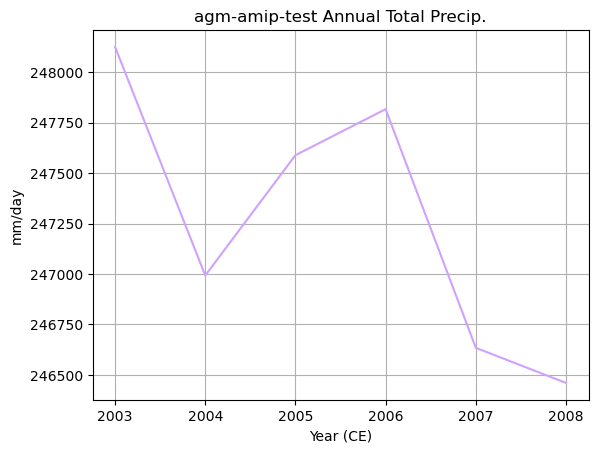

In [7]:
# All precip
ds_pr_daily = 86400. * get_ds(
                    "pr",
                    my_runid, 
                    my_experiment_name,
                    year_range,
                    base_path = my_base_path,
                    file_path = my_file_path,
)

pr_gm = (ds_areacella.areacella * ds_pr_daily.pr).sum(dim=['lon', 'lat']) / global_area # Properly area weighted mean of rate of flux
time_scale = 60*60*24 # Number of seconds in a day 
(time_scale*pr_gm.groupby('time.year').mean(dim='time')).plot(color="xkcd:lilac")
plt.grid()
plt.title("agm-amip-test Annual Total Precip.")
plt.xlabel("Year (CE)")
plt.ylabel("mm/day")
pr_mean = time_scale*pr_gm.mean(dim='time').values
pr_mean